In [1]:
#Bibliotecas
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Função para apresentação da imagem
def apresentaImg(imagem):
    img = plt.figure(figsize=(30,28))
    ax = img.add_subplot(111)
    ax.imshow(imagem, cmap = 'gray')
    plt.show()
    
#Carregando as Imagens
leite_condensado = cv2.imread('leite_condensado.jpg')
leite_condensado = cv2.cvtColor(leite_condensado, cv2.COLOR_BGR2GRAY)

pratileira_leite = cv2.imread('pratileira_leite.jpg')
pratileira_leite = cv2.cvtColor(pratileira_leite, cv2.COLOR_BGR2GRAY)


In [2]:
#sift = cv2.xfeatures2d.SIFT_create() Depreciado
#Substituir por
sift = cv2.SIFT_create()  # Aqui, corrigido para cv2.SIFT_create()


In [3]:
kp1, des1 = sift.detectAndCompute(leite_condensado, None)
kp2, des2 = sift.detectAndCompute(pratileira_leite, None)

In [4]:
forcaBruta = cv2.BFMatcher()

In [5]:
matches = forcaBruta.knnMatch(des1, des2, k = 2)

In [6]:
#matches

In [7]:
good = []

for match1, match2 in matches:
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [8]:
len(matches)

8294

In [9]:
len(good)

133

In [10]:
sift_matches = cv2.drawMatchesKnn(leite_condensado, kp1, pratileira_leite, kp2, good, None, flags = 2)

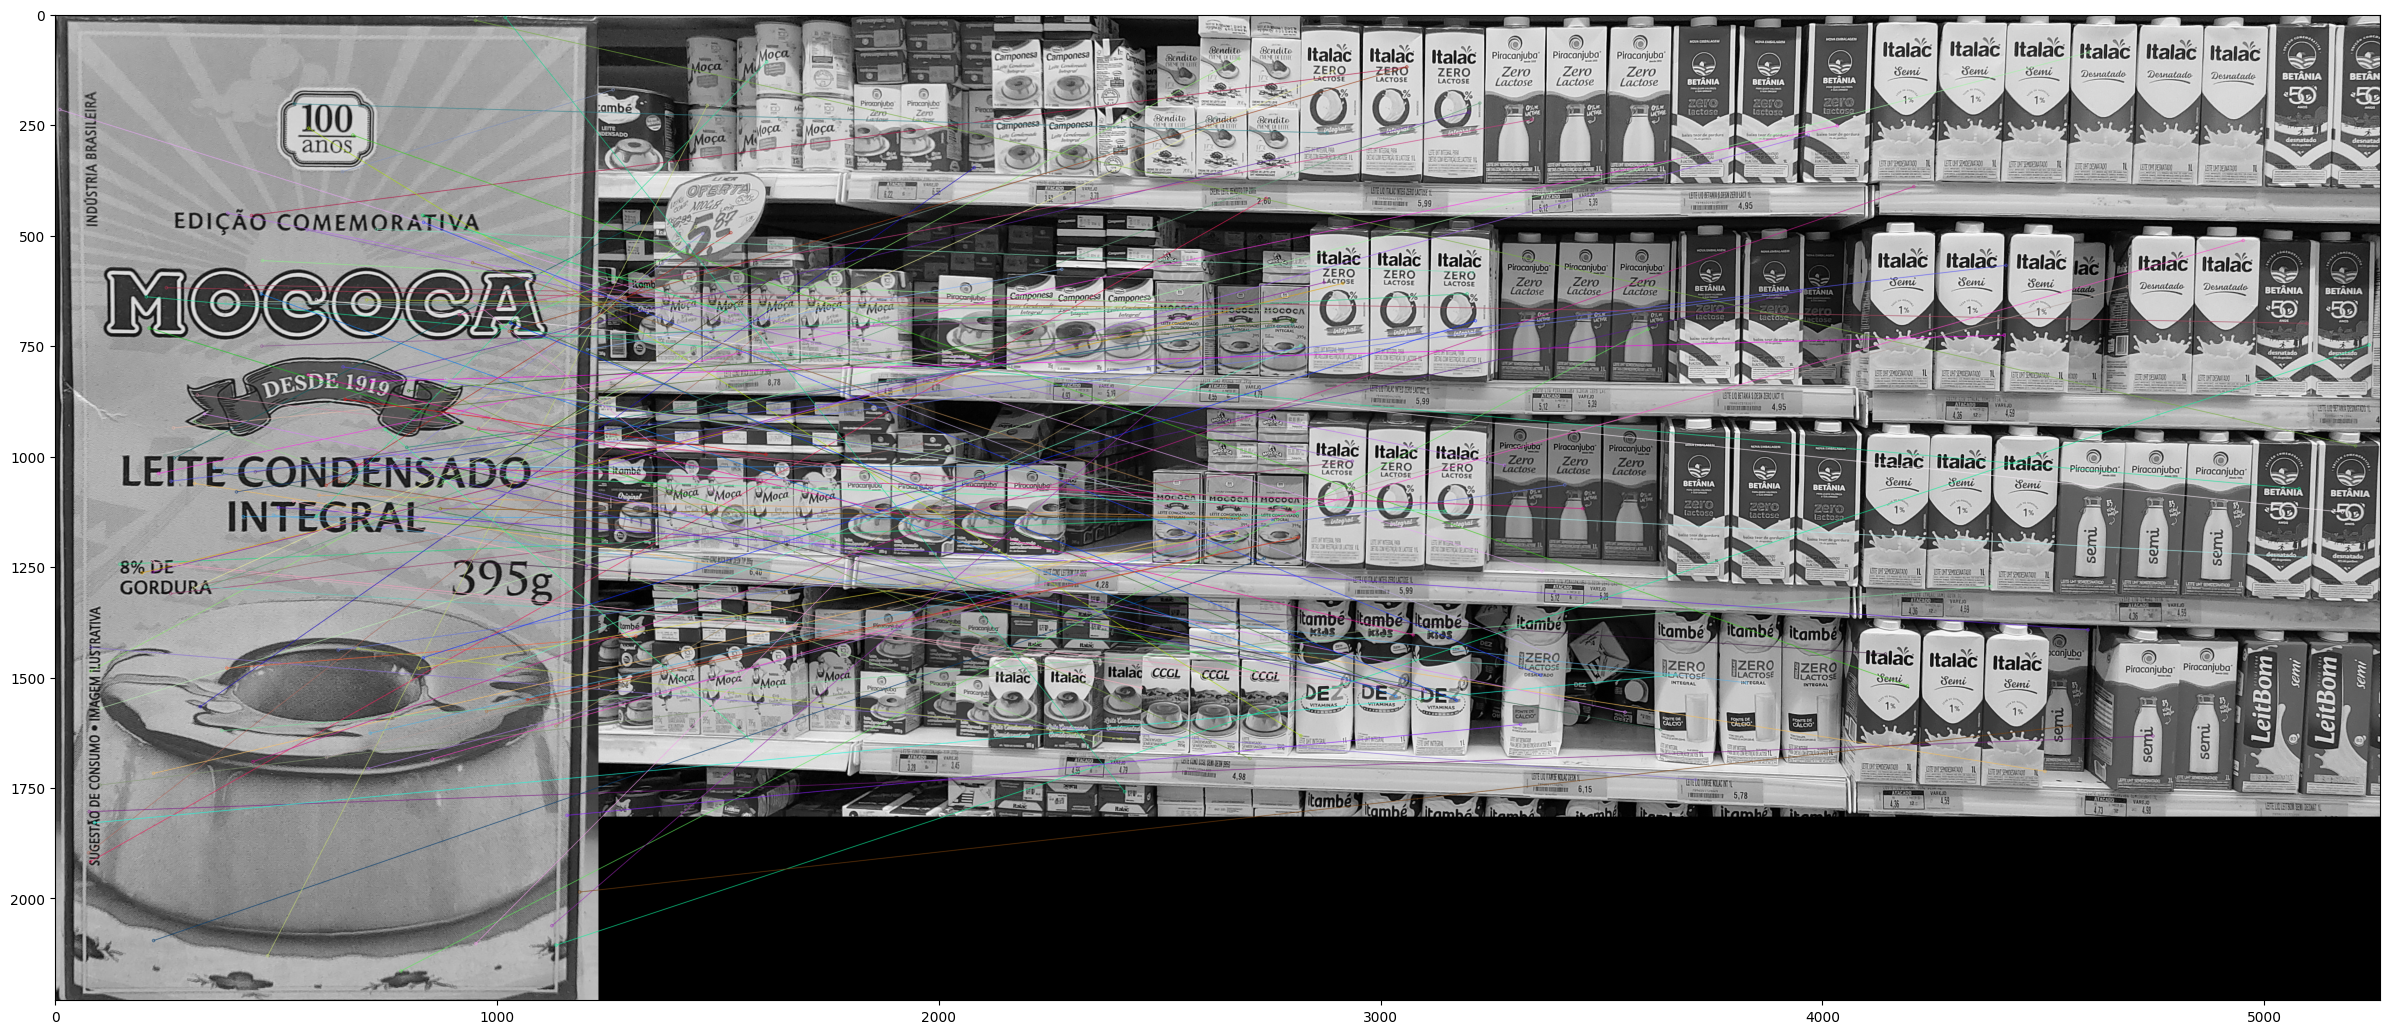

In [11]:
apresentaImg(sift_matches)